In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report

In [ ]:
df=pd.read_csv('Crop_recommendation.csv')
df

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee


In [ ]:
print(df.info())

df.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB
None


,0
N,int64
P,int64
K,int64
temperature,float64
humidity,float64
ph,float64
rainfall,float64
label,object


In [ ]:
df.isnull().sum()

,0
N,0
P,0
K,0
temperature,0
humidity,0
ph,0
rainfall,0
label,0


In [ ]:
def get_season(row):

    if row['rainfall'] > 200:
        return "Kharif"
    elif row['temperature'] < 25:
        return "Rabi"
    else:
        return "Zaid"

df['season'] = df.apply(get_season, axis=1)

In [ ]:
from sklearn.preprocessing import LabelEncoder

season_encoder = LabelEncoder()

df['season'] = season_encoder.fit_transform(df['season'])

In [ ]:
df['label'].unique()

array(['rice', 'maize', 'chickpea', 'kidneybeans', 'pigeonpeas',
       'mothbeans', 'mungbean', 'blackgram', 'lentil', 'pomegranate',
       'banana', 'mango', 'grapes', 'watermelon', 'muskmelon', 'apple',
       'orange', 'papaya', 'coconut', 'cotton', 'jute', 'coffee'],
      dtype=object)

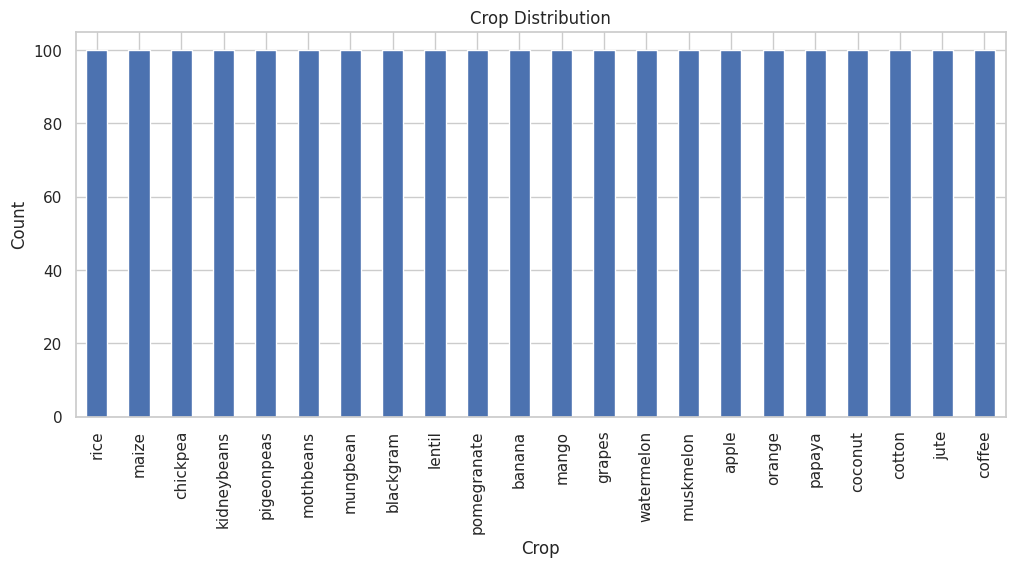

In [ ]:
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar', figsize=(12,5))
plt.title("Crop Distribution")
plt.xlabel("Crop")
plt.ylabel("Count")
plt.show()

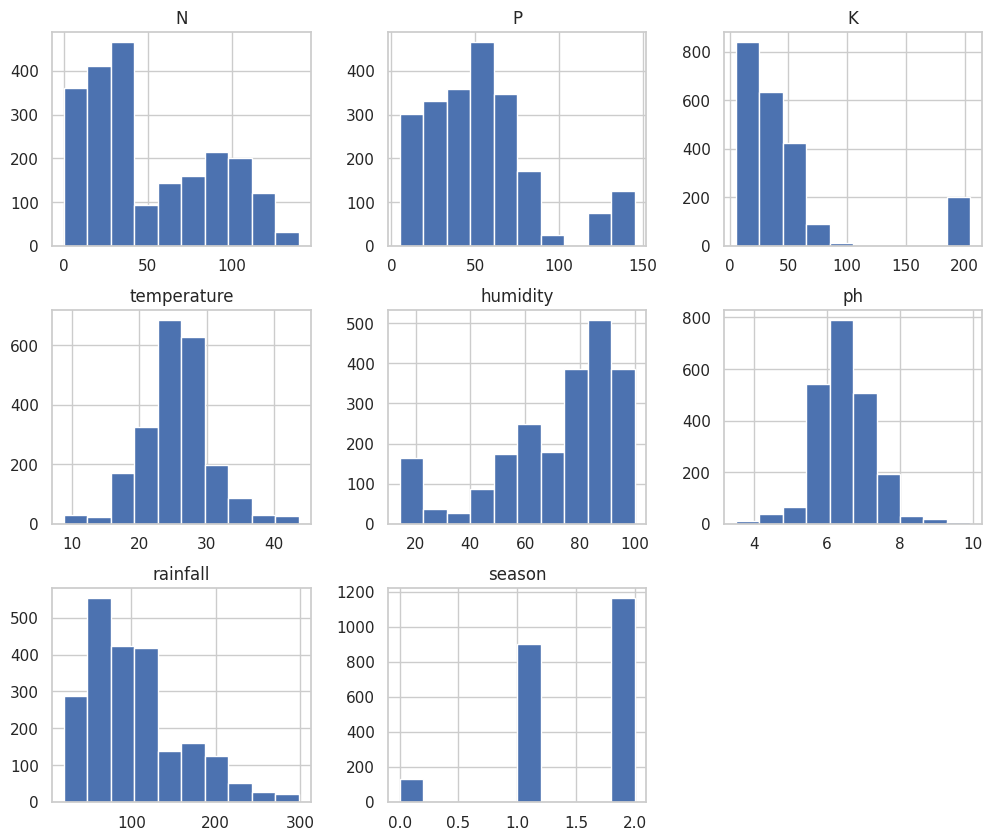

In [ ]:
df.hist(figsize=(12,10))
plt.show()

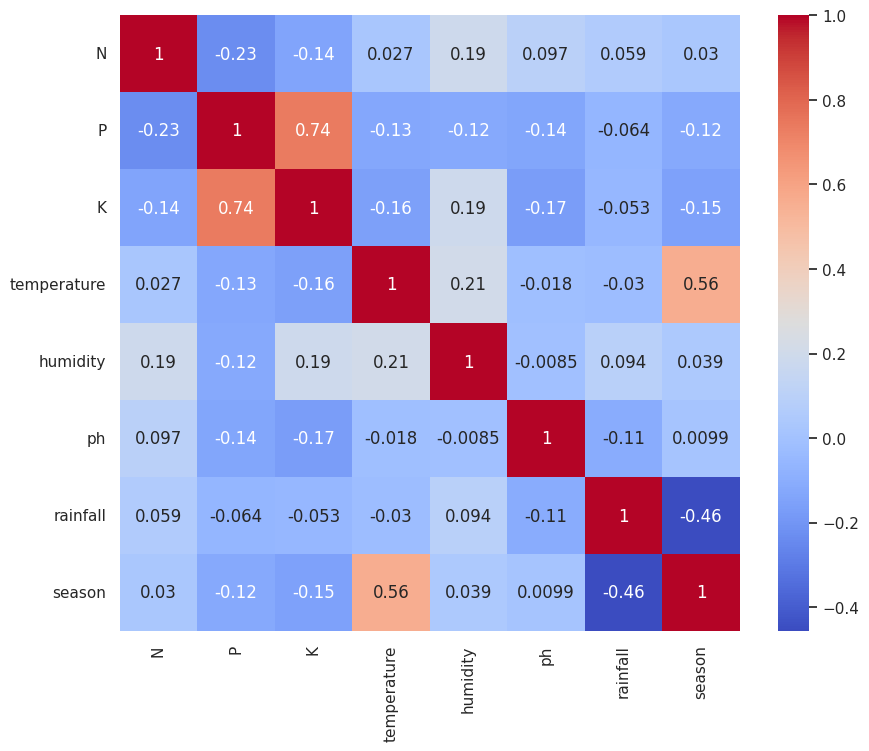

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df.drop('label', axis=1).corr(), annot=True, cmap='coolwarm')
plt.show()

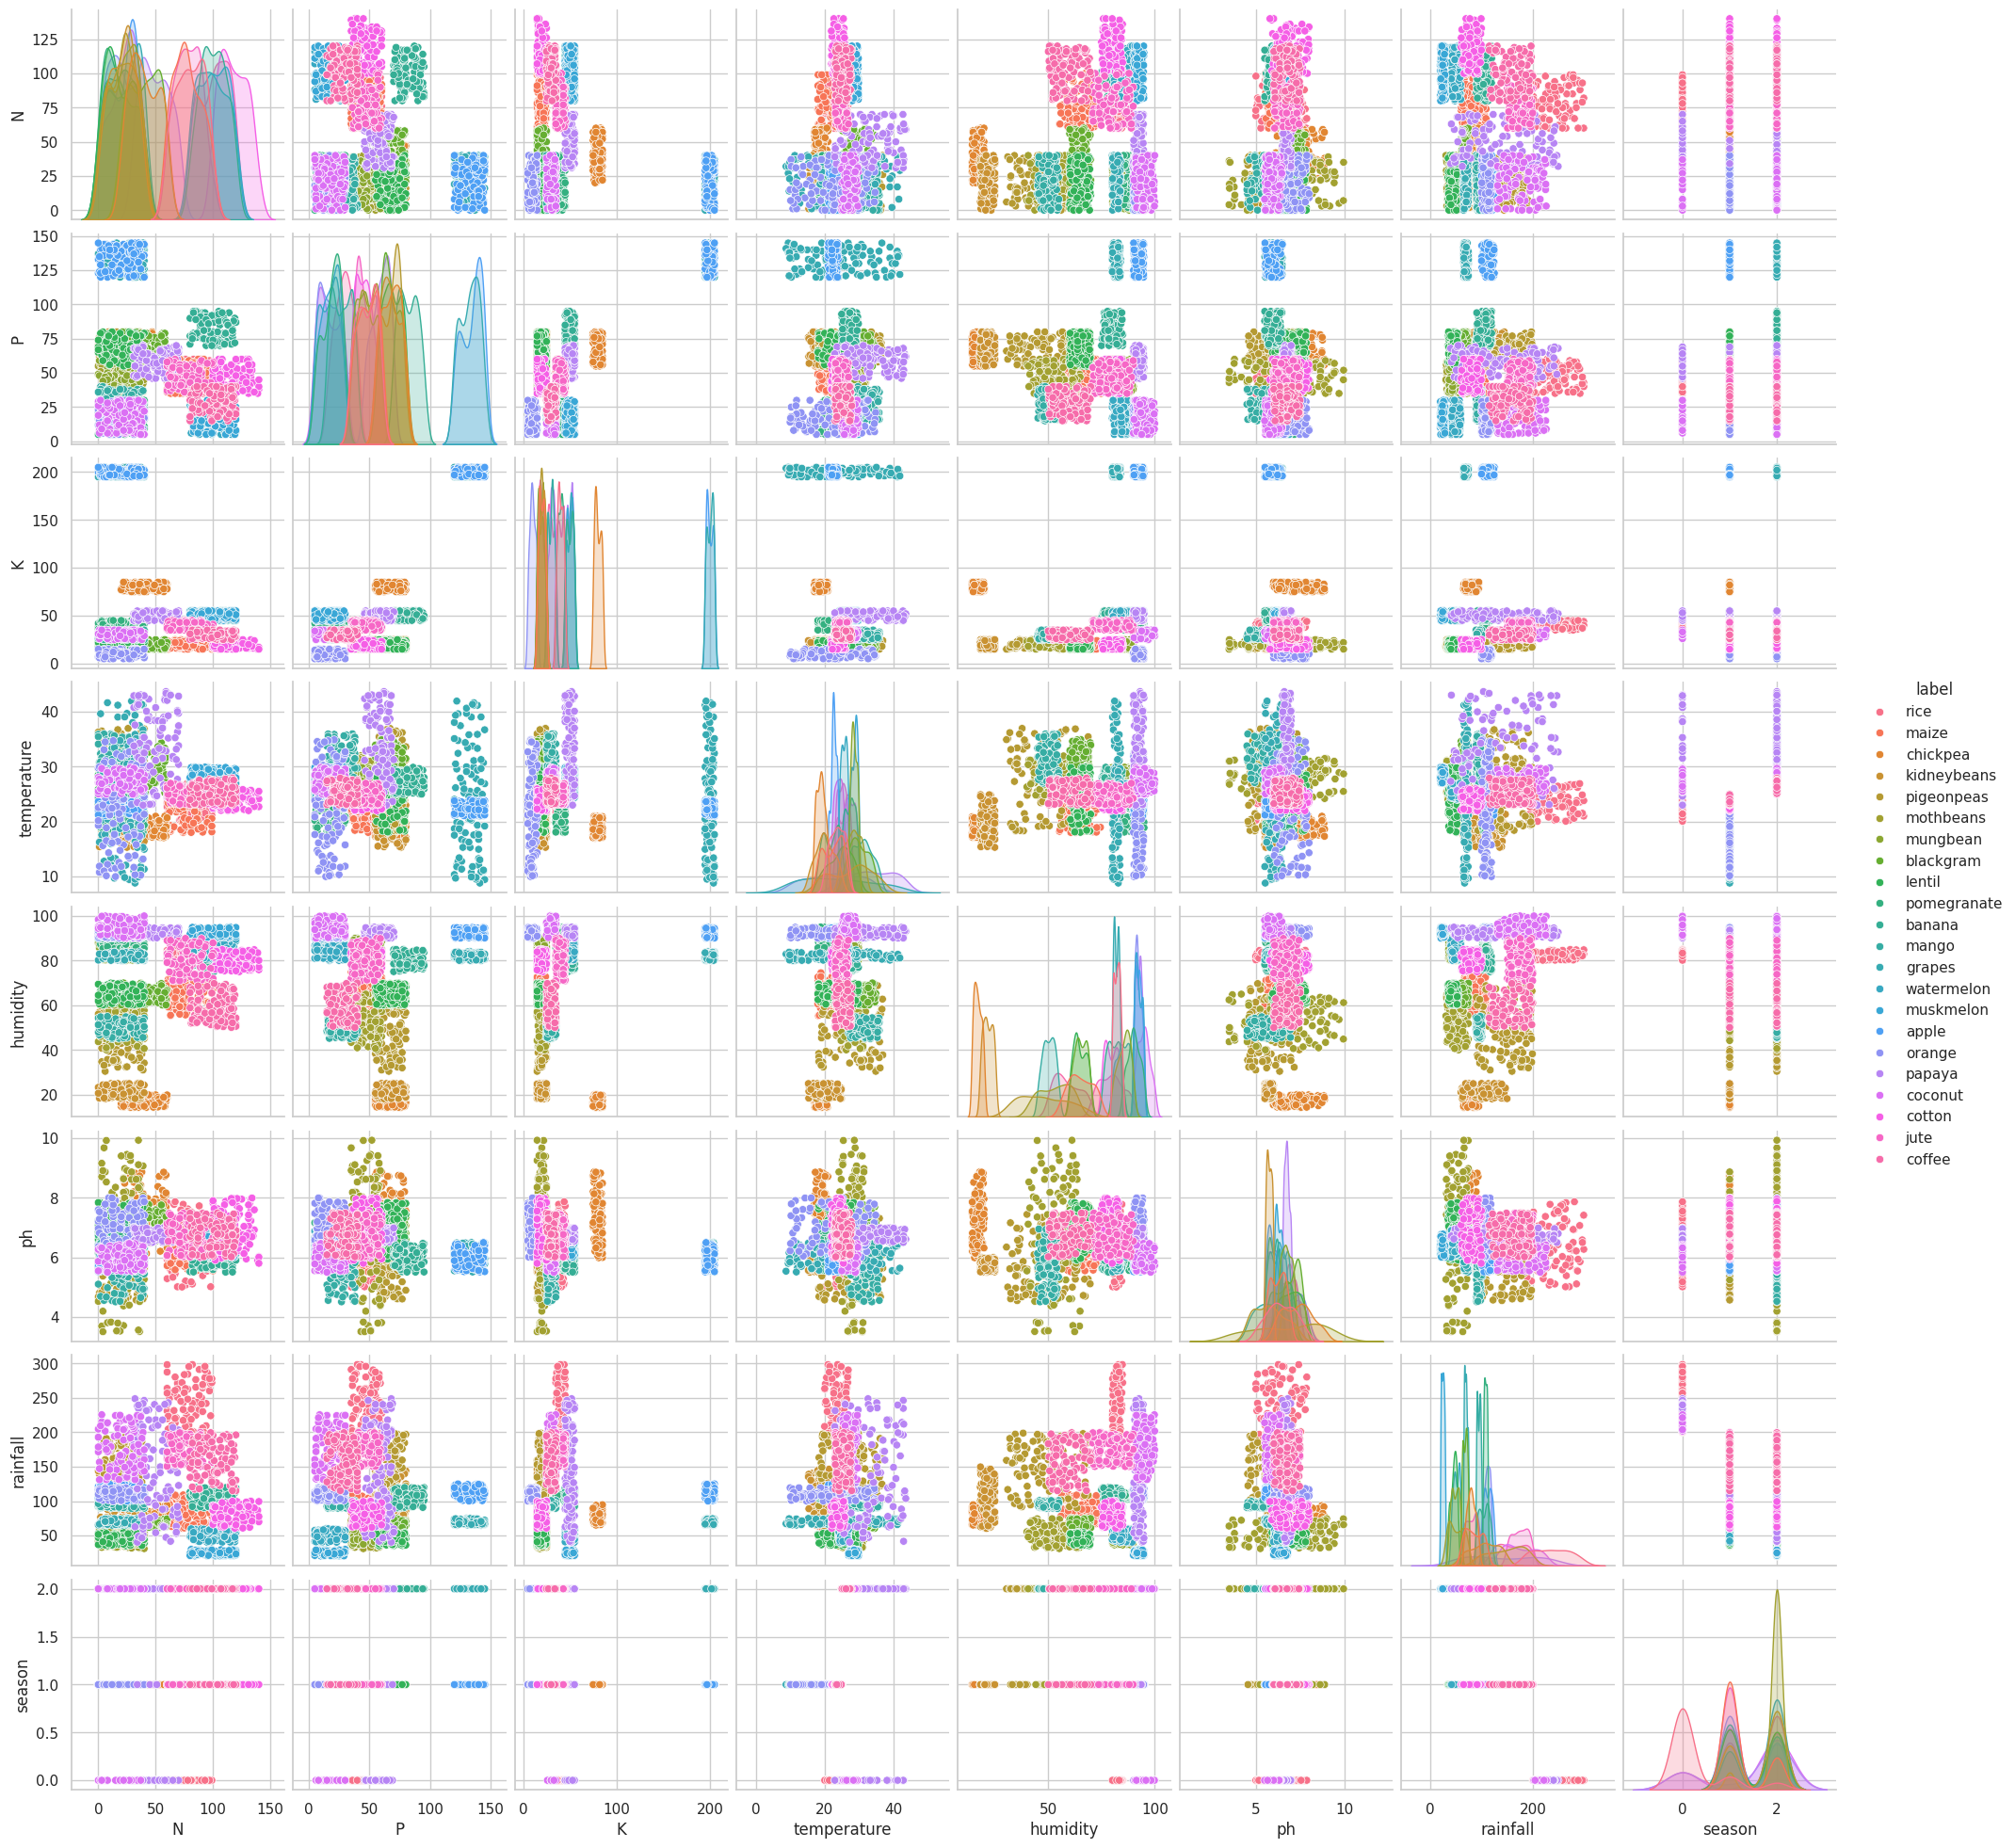

In [ ]:
sns.pairplot(df, hue='label')
plt.show()

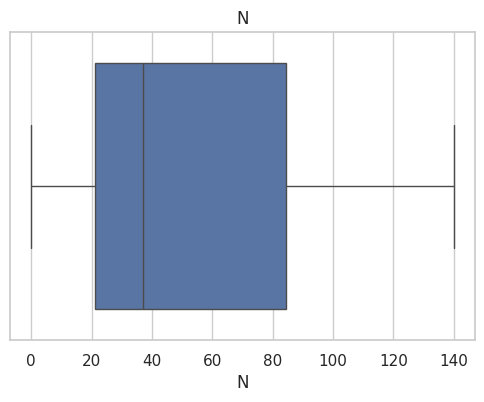

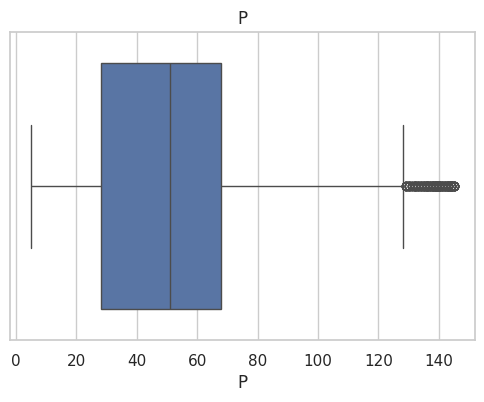

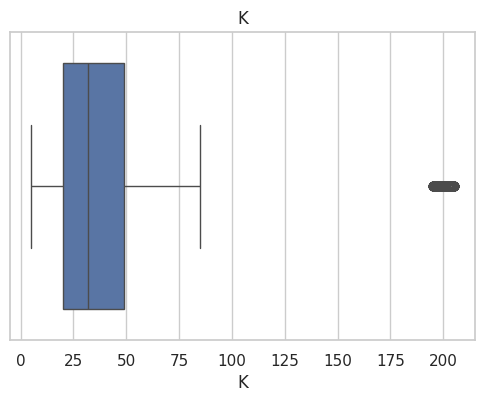

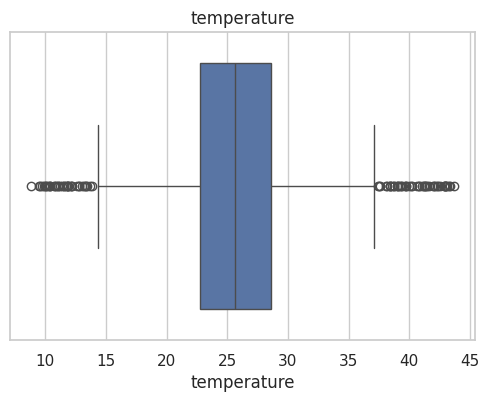

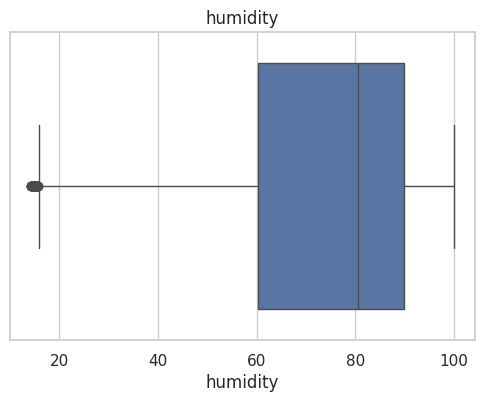

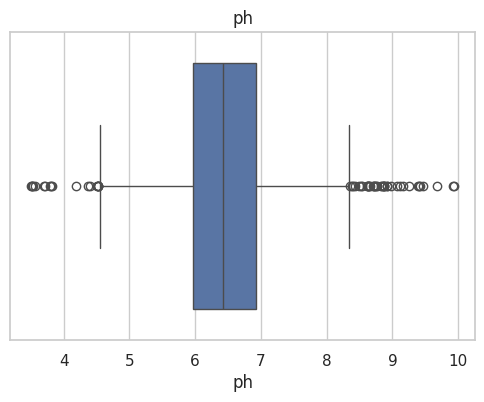

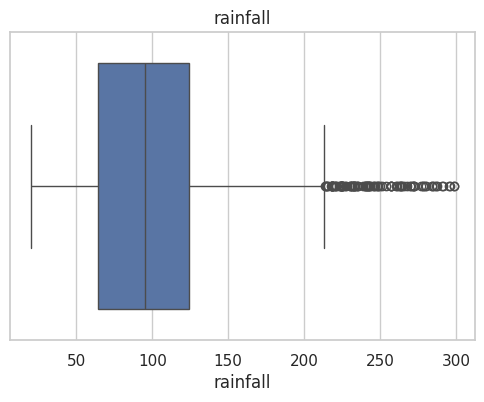

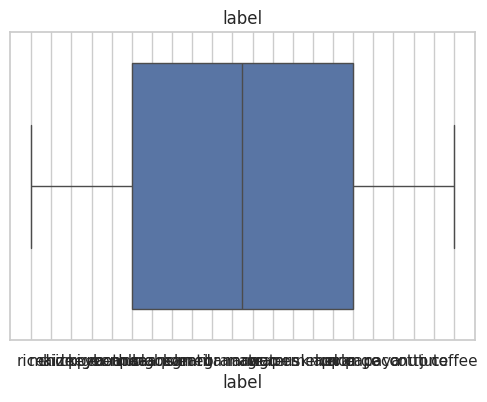

In [ ]:
for col in df.columns[:-1]:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

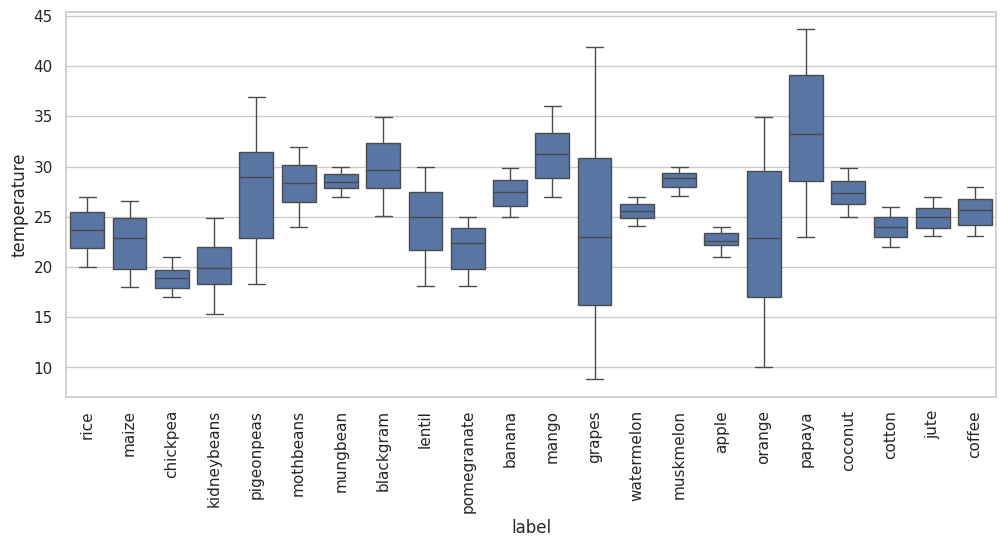

In [ ]:
plt.figure(figsize=(12,5))
sns.boxplot(x='label', y='temperature', data=df)
plt.xticks(rotation=90)
plt.show()

In [ ]:
x = df.drop('label', axis=1).values
y = df['label'].values

In [ ]:
le=LabelEncoder()
y=le.fit_transform(y)
y

array([20, 20, 20, ...,  5,  5,  5])

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)

In [ ]:
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(n_estimators=100,random_state=0)
rf.fit(x_train,y_train)
rf_pred=rf.predict(x_test)
print(classification_report(y_test, rf_pred))
print("Accuracy:",accuracy_score(y_test,rf_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      1.00      1.00        18
           2       1.00      1.00      1.00        22
           3       1.00      1.00      1.00        23
           4       1.00      1.00      1.00        15
           5       1.00      1.00      1.00        17
           6       1.00      1.00      1.00        16
           7       1.00      1.00      1.00        18
           8       0.95      1.00      0.98        21
           9       1.00      1.00      1.00        20
          10       0.94      1.00      0.97        17
          11       1.00      1.00      1.00        18
          12       1.00      1.00      1.00        21
          13       1.00      0.96      0.98        25
          14       1.00      1.00      1.00        17
          15       1.00      1.00      1.00        23
          16       1.00      1.00      1.00        23
          17       1.00    

In [ ]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression(random_state=0)
lr.fit(x_train,y_train)
lr_pred=lr.predict(x_test)
print(classification_report(y_test, lr_pred))
print("Accuracy:",accuracy_score(y_test,lr_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      1.00      1.00        18
           2       0.87      0.91      0.89        22
           3       1.00      1.00      1.00        23
           4       1.00      1.00      1.00        15
           5       1.00      1.00      1.00        17
           6       1.00      1.00      1.00        16
           7       1.00      1.00      1.00        18
           8       0.88      1.00      0.93        21
           9       0.95      1.00      0.98        20
          10       0.78      0.82      0.80        17
          11       1.00      1.00      1.00        18
          12       1.00      1.00      1.00        21
          13       0.95      0.80      0.87        25
          14       1.00      1.00      1.00        17
          15       0.96      1.00      0.98        23
          16       1.00      1.00      1.00        23
          17       1.00    

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier(criterion='entropy',random_state=0)
dt.fit(x_train,y_train)
dt_pred=dt.predict(x_test)
print(classification_report(y_test, dt_pred))
print("Accuracy:",accuracy_score(y_test,dt_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      1.00      1.00        18
           2       1.00      0.91      0.95        22
           3       1.00      1.00      1.00        23
           4       1.00      1.00      1.00        15
           5       1.00      0.88      0.94        17
           6       1.00      1.00      1.00        16
           7       1.00      1.00      1.00        18
           8       1.00      0.95      0.98        21
           9       0.95      1.00      0.98        20
          10       1.00      1.00      1.00        17
          11       0.86      1.00      0.92        18
          12       1.00      1.00      1.00        21
          13       0.96      0.96      0.96        25
          14       1.00      1.00      1.00        17
          15       1.00      1.00      1.00        23
          16       1.00      1.00      1.00        23
          17       1.00    

In [ ]:
from sklearn.svm import SVC
svm=SVC(kernel='linear',random_state=0)
svm.fit(x_train,y_train)
svm_pred=svm.predict(x_test)
print(classification_report(y_test, svm_pred))
print("Accuracy:",accuracy_score(y_test,svm_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      1.00      1.00        18
           2       1.00      1.00      1.00        22
           3       1.00      1.00      1.00        23
           4       1.00      1.00      1.00        15
           5       1.00      1.00      1.00        17
           6       1.00      1.00      1.00        16
           7       1.00      1.00      1.00        18
           8       0.91      0.95      0.93        21
           9       0.95      1.00      0.98        20
          10       0.89      0.94      0.91        17
          11       1.00      1.00      1.00        18
          12       1.00      1.00      1.00        21
          13       0.96      0.92      0.94        25
          14       1.00      1.00      1.00        17
          15       1.00      1.00      1.00        23
          16       1.00      1.00      1.00        23
          17       1.00    

In [ ]:
from sklearn.naive_bayes import GaussianNB
nb=GaussianNB()
nb.fit(x_train,y_train)
nb_pred=nb.predict(x_test)
print(classification_report(y_test, nb_pred))
print("Accuracy:",accuracy_score(y_test,nb_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      1.00      1.00        18
           2       0.88      1.00      0.94        22
           3       1.00      1.00      1.00        23
           4       1.00      1.00      1.00        15
           5       1.00      1.00      1.00        17
           6       1.00      1.00      1.00        16
           7       1.00      1.00      1.00        18
           8       0.91      1.00      0.95        21
           9       1.00      1.00      1.00        20
          10       0.88      0.82      0.85        17
          11       1.00      0.94      0.97        18
          12       1.00      1.00      1.00        21
          13       0.95      0.84      0.89        25
          14       1.00      1.00      1.00        17
          15       1.00      1.00      1.00        23
          16       1.00      1.00      1.00        23
          17       1.00    

In [ ]:
model_results = {
    "Model": ["Logistic Regression", "Decision Tree", "SVM", "Navie Bayes", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, svm_pred),
        accuracy_score(y_test,  nb_pred),
        accuracy_score(y_test, rf_pred)
    ]}

results_df = pd.DataFrame(model_results)


/tmp/ipykernel_3929/2105616688.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Accuracy", y="Model", data=results_df, palette="viridis")


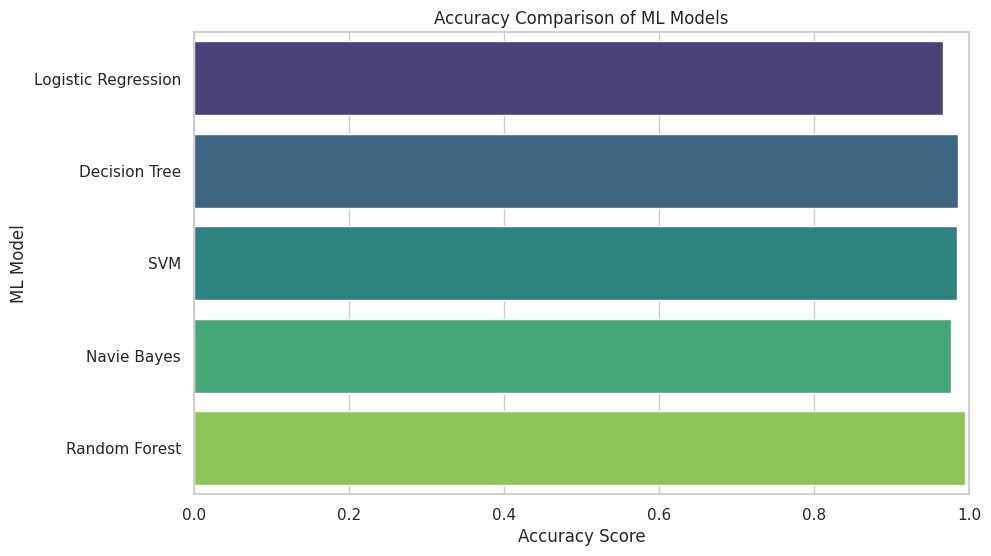

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="whitegrid")

# Plot Accuracy
plt.figure(figsize=(10, 6))
sns.barplot(x="Accuracy", y="Model", data=results_df, palette="viridis")
plt.title("Accuracy Comparison of ML Models")
plt.xlabel("Accuracy Score")
plt.ylabel("ML Model")
plt.xlim(0, 1)
plt.show()

In [ ]:
season = season_encoder.transform(['Kharif'])[0]

sample = np.array([[60,55,44,23.004459,82.320763,7.840207,263.964248,season]])

sample = sc.transform(sample)

prediction = rf.predict(sample)

crop = le.inverse_transform(prediction)

print("Recommended Crop:", crop[0])

Recommended Crop: rice


In [ ]:
import pickle

pickle.dump(rf, open("crop_recc_model.pkl", "wb"))
pickle.dump(sc, open("crop_recc_scaler.pkl", "wb"))
pickle.dump(le, open("crop_recc_label_encoder.pkl", "wb"))
pickle.dump(season_encoder, open("crop_recc_season_encoder.pkl", "wb"))